In [1]:
# ══════════════════════════════════════════════════════════════════════
# RECOMMENDED COMPUTE — autoencoder + feature selection
#   >>> gpu-8c-l4-1g  (8 cores, 64 GB RAM, 1x NVIDIA L4 24 GB, ~RM8.27/hr) <-- pick
#   Why: the autoencoder trains on the GPU (far faster than CPU); the L4's
#        24 GB fits the single-pass encoding of the full ~18 M-row set.
#   CPU-only alt: cpu-16c-std (128 GB, ~RM8.99/hr) - safe, slower AE training.
# ══════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────
# SETUP — Portable project root (RUN THIS CELL FIRST)
#
# Sets the working directory to the ML-IDS project root so every relative
# path in this notebook resolves regardless of where Jupyter was launched.
# Override by exporting ML_IDS_ROOT=/path/to/ML-IDS before starting Jupyter.
# ──────────────────────────────────────────────────────────────────
import os
from pathlib import Path

def _find_project_root():
    for cand in (Path.cwd(), *Path.cwd().parents):
        if (cand / 'data').is_dir() and (cand / 'notebooks').is_dir():
            return cand
    return Path.cwd()

os.chdir(os.environ.get('ML_IDS_ROOT') or _find_project_root())
print('Project root:', os.getcwd())

Project root: /home/user/22056253/ML-IDS


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# CELL 0 — Load processed data
#
# Loads the partially SMOTE-oversampled training set (18.41 M rows, 77
# features), plus the real val and test sets, produced by the preprocessing
# notebook.
# NOTE: the training set is NOT fully class-balanced. SMOTE raised each
# minority class to min(50x its original count, ~10% of Benign) and left
# Benign untouched, so the set remains ~3000:1 imbalanced (Benign 9.44 M vs
# SQL Injection 3,050). Downstream classifiers MUST use class weights /
# balanced loss — see the class_weights.npy saved in Cell 9.
# These are the MinMaxScaler-normalised [0,1] features ready for the
# autoencoder and feature selection steps below.
# ─────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import joblib
import os

# Load saved data
X_train = np.load('data/processed/X_train.npy')
y_train = np.load('data/processed/y_train.npy')
X_val   = np.load('data/processed/X_val.npy')
y_val   = np.load('data/processed/y_val.npy')
X_test  = np.load('data/processed/X_test.npy')
y_test  = np.load('data/processed/y_test.npy')
le      = joblib.load('models/label_encoder.pkl')

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

In [13]:
# ─────────────────────────────────────────────────────────────────────
# CELL 1 — Define Autoencoder architecture
#
# Defines a symmetric autoencoder: 77 → 64 → 32 → 16 (encoder)
# and 16 → 32 → 64 → 77 (decoder).
#
# Two deliberate choices to prevent latent collapse (the previous ReLU
# version left 9 of 16 bottleneck dims dead — constant 0 for all inputs —
# so the "16-dim" latent block was really only 7 informative dims):
#   1. LeakyReLU(0.01) instead of ReLU in every hidden layer, so a neuron
#      that drifts negative still passes a small gradient and can recover
#      rather than dying permanently.
#   2. NO activation on the bottleneck (linear latent). A terminal ReLU
#      forces every latent dim to be >= 0 and hard-zeros any dim whose
#      pre-activation is negative; a linear bottleneck lets all 16 dims
#      carry signed, full-range signal.
# The decoder keeps a Sigmoid output so reconstructions stay in [0,1] to
# match the MinMaxScaler-normalised input range.
# ─────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f"Using device: {device}")

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()

        # Encoder: LeakyReLU hidden layers, LINEAR bottleneck (no final activation)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.LeakyReLU(0.01),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.01),
            nn.Linear(32, 16)          # linear latent — signed, no dead-ReLU collapse
        )

        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.LeakyReLU(0.01),
            nn.Linear(32, 64),
            nn.LeakyReLU(0.01),
            nn.Linear(64, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

    def encode(self, x):
        return self.encoder(x)

input_dim = X_train.shape[1]
model = Autoencoder(input_dim).to(device)
print(model)
print(f"\nInput dimension: {input_dim}")
print(f"Latent dimension: 16")

Using device: cuda
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=77, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=32, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=64, out_features=77, bias=True)
    (5): Sigmoid()
  )
)

Input dimension: 77
Latent dimension: 16


In [14]:
# ─────────────────────────────────────────────────────────────────────
# CELL 2 — Train autoencoder on real traffic only
#
# Trains the autoencoder using MSE reconstruction loss with Adam optimiser
# and patience-10 early stopping on validation loss.
# Critically, training uses X_train_original (pre-SMOTE real flows) rather
# than the SMOTE-balanced set. SMOTE samples are linear interpolations between
# real flows; training reconstruction on them biases the latent space toward
# convex-combination artefacts and degrades the quality of the latent features
# that downstream classifiers rely on.
# ─────────────────────────────────────────────────────────────────────
from torch.utils.data import DataLoader, TensorDataset

# Train the autoencoder on pre-SMOTE real traffic only.
# SMOTE synthetic samples are linear interpolations — training reconstruction on
# them biases the latent space toward convex-combination artefacts rather than
# real network-flow patterns. X_train_original.npy was saved for exactly this.
X_ae = np.load('data/processed/X_train_original.npy')
X_ae_f32  = X_ae.astype(np.float32, copy=False)   # zero-copy if already float32
X_val_f32 = X_val.astype(np.float32, copy=False)

train_loader = DataLoader(TensorDataset(torch.from_numpy(X_ae_f32),  torch.from_numpy(X_ae_f32)),
                          batch_size=4096, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(TensorDataset(torch.from_numpy(X_val_f32), torch.from_numpy(X_val_f32)),
                          batch_size=4096, shuffle=False,
                          num_workers=0, pin_memory=False)

criterion        = nn.MSELoss()
optimizer        = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs       = 100
best_val_loss    = float('inf')
patience         = 10
patience_counter = 0

print(f'Starting Autoencoder training on {device} (real traffic only, {len(X_ae_f32):,} rows)...')
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch_x, _ in train_loader:
        batch_x = batch_x.to(device)
        optimizer.zero_grad()
        loss = criterion(model(batch_x), batch_x)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x, _ in val_loader:
            batch_x = batch_x.to(device)
            val_loss += criterion(model(batch_x), batch_x).item()

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'models/autoencoder.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

print(f'Training complete! Best val loss: {best_val_loss:.6f}')

Starting Autoencoder training on cuda (real traffic only, 11,363,060 rows)...
Epoch 10/100 | Train Loss: 0.000348 | Val Loss: 0.000347
Epoch 20/100 | Train Loss: 0.000212 | Val Loss: 0.000191
Epoch 30/100 | Train Loss: 0.000161 | Val Loss: 0.000162
Epoch 40/100 | Train Loss: 0.000031 | Val Loss: 0.000031
Epoch 50/100 | Train Loss: 0.000030 | Val Loss: 0.000030
Epoch 60/100 | Train Loss: 0.000030 | Val Loss: 0.000030
Epoch 70/100 | Train Loss: 0.000030 | Val Loss: 0.000030
Epoch 80/100 | Train Loss: 0.000031 | Val Loss: 0.000031
Epoch 90/100 | Train Loss: 0.000029 | Val Loss: 0.000029
Epoch 100/100 | Train Loss: 0.000029 | Val Loss: 0.000029
Training complete! Best val loss: 0.000029


In [15]:
# ─────────────────────────────────────────────────────────────────────
# CELL 3 — Encode all splits into 16-dim latent vectors
#
# Loads the best autoencoder checkpoint and encodes the full SMOTE training
# set, val set, and test set into 16-dimensional latent vectors in a single
# forward pass each (no batching — the full run has the memory for it).
# X_ae (pre-SMOTE) is also encoded separately so the latent scaler (cell 8)
# can be fitted on REAL-data encodings: SMOTE rows are linear interpolations
# between real flows, so their latent range is artificially compressed toward
# class centroids and would give the scaler a distorted min/max. Fitting on
# real encodings keeps the scale faithful to genuine traffic.
# ─────────────────────────────────────────────────────────────────────
model.load_state_dict(
    torch.load('models/autoencoder.pth', weights_only=True)
)
model.eval()
model = model.to(device)

# Reload X_ae if this cell is run after a kernel restart (checkpoint is on disk,
# so cell 2 training can be skipped, but X_ae must still be available).
try:
    X_ae
except NameError:
    X_ae = np.load('data/processed/X_train_original.npy')

def encode_all(model, X):
    """Encode X in a single forward pass. float32 cast is required by torch."""
    X_t = torch.from_numpy(X.astype(np.float32, copy=False)).to(device)
    with torch.no_grad():
        return model.encode(X_t).cpu().numpy()

# Encode the full SMOTE training set — classifiers train on these latent features.
X_train_latent = encode_all(model, X_train)
X_val_latent   = encode_all(model, X_val)
X_test_latent  = encode_all(model, X_test)

# Encode the original (pre-SMOTE) training set — used to fit latent_scaler on
# real-traffic encodings (see cell 8) rather than SMOTE-interpolated ones.
X_ae_latent_for_scale = encode_all(model, X_ae)

# Sanity check: with the LeakyReLU + linear-bottleneck AE, every latent dim
# should now carry variance (the old ReLU version left 9/16 dead at exactly 0).
_alive = int((X_ae_latent_for_scale.var(axis=0) > 1e-9).sum())
print(f'Live latent dims (variance > 1e-9): {_alive}/16')
if _alive < 16:
    print(f'  WARNING: {16 - _alive} latent dim(s) still collapsed — '
          f'consider lowering lr or increasing epochs.')

print(f'Latent train shape: {X_train_latent.shape}')
print(f'Latent val shape:   {X_val_latent.shape}')
print(f'Latent test shape:  {X_test_latent.shape}')

Live latent dims (variance > 1e-9): 16/16
Latent train shape: (18412356, 16)
Latent val shape:   (2434941, 16)
Latent test shape:  (2434942, 16)


In [6]:
# ─────────────────────────────────────────────────────────────────────
# CELL 4 — Mutual Information feature selection (top-40)
#
# Computes Mutual Information between each of the 77 features and the class
# label on a 200 000-row random sample of real (pre-SMOTE) training data.
# (MI's k-NN estimator is O(n log n) per feature; 200k gives high-fidelity
# rankings while still finishing in minutes. Raise MI_SAMPLE to len(X_orig)
# for the full-data estimate if you want it.)
# MI is used instead of ANOVA F-score or variance because it captures
# non-linear statistical dependencies — important for network traffic where
# attack signatures often appear as distributional shape differences, not
# just mean shifts detectable by linear methods.
# The top-40 features by MI score are selected. Near-constant features are
# noted diagnostically but not excluded — MI ranking handles them naturally
# by assigning them near-zero scores.
# ─────────────────────────────────────────────────────────────────────
from sklearn.feature_selection import mutual_info_classif
import numpy as np

print('Computing Mutual Information scores on original (pre-SMOTE) training data...')

X_orig = np.load('data/processed/X_train_original.npy')
y_orig = np.load('data/processed/y_train_original.npy')

MI_SAMPLE = 200_000   # set to len(X_orig) for the full-data MI estimate
np.random.seed(42)
sample_idx = np.random.choice(len(X_orig), min(MI_SAMPLE, len(X_orig)), replace=False)
X_sample = X_orig[sample_idx]
y_sample = y_orig[sample_idx]

mi_scores = mutual_info_classif(X_sample, y_sample, random_state=42)

mi_sorted_idx = np.argsort(mi_scores)[::-1]
print(f'\nTop 20 features by Mutual Information:')
for i in range(20):
    idx = mi_sorted_idx[i]
    print(f'  Feature {idx}: {mi_scores[idx]:.4f}')

# Diagnostic only — do NOT exclude from selection.
# Features with near-zero variance can still carry real MI signal (skewed
# distributions compressed by MinMaxScaler). MI ranking already handles this:
# truly uninformative features score 0 and never enter the top-k.
constant_mask = np.var(X_sample, axis=0) < 1e-8
constant_feat_idx = [int(i) for i in np.where(constant_mask)[0]]
if constant_feat_idx:
    print(f'\nNear-constant features (diagnostic only, not excluded): {constant_feat_idx}')

top_k = 40
selected_indices = mi_sorted_idx[:top_k]
print(f'\nSelected top-{top_k} features out of {X_train.shape[1]} by MI score')

# Persist so downstream cells can run standalone without re-running this cell.
# selected_indices.npy is saved here (not just in Cell 9) so Cell 7's restart
# fallback works even if the kernel was restarted before Cell 9 was reached.
np.save('models/selected_indices.npy', selected_indices)
np.save('models/feat_sel_mi_scores.npy', mi_scores)
np.save('models/feat_sel_X_sample.npy',  X_sample)
np.save('models/feat_sel_y_sample.npy',  y_sample)

Computing Mutual Information scores on original (pre-SMOTE) training data...

Top 20 features by Mutual Information:
  Feature 65: 0.5698
  Feature 36: 0.3761
  Feature 34: 0.3716
  Feature 15: 0.3673
  Feature 23: 0.3404
  Feature 20: 0.3349
  Feature 18: 0.3345
  Feature 1: 0.3183
  Feature 21: 0.3119
  Feature 37: 0.3101
  Feature 4: 0.3090
  Feature 62: 0.3076
  Feature 6: 0.3064
  Feature 8: 0.3035
  Feature 53: 0.3024
  Feature 12: 0.2950
  Feature 16: 0.2946
  Feature 39: 0.2945
  Feature 54: 0.2931
  Feature 5: 0.2930

Near-constant features (diagnostic only, not excluded): [1, 16, 17, 18, 19, 20, 21, 22, 23, 24, 31, 33, 55, 56, 57, 58, 59, 60, 73, 74, 75, 76]

Selected top-40 features out of 77 by MI score


Computing ANOVA F-scores and variance on the same sample...


/home/user/22056253/.local/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [31 33 55 56 57 58 59 60] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/user/22056253/.local/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


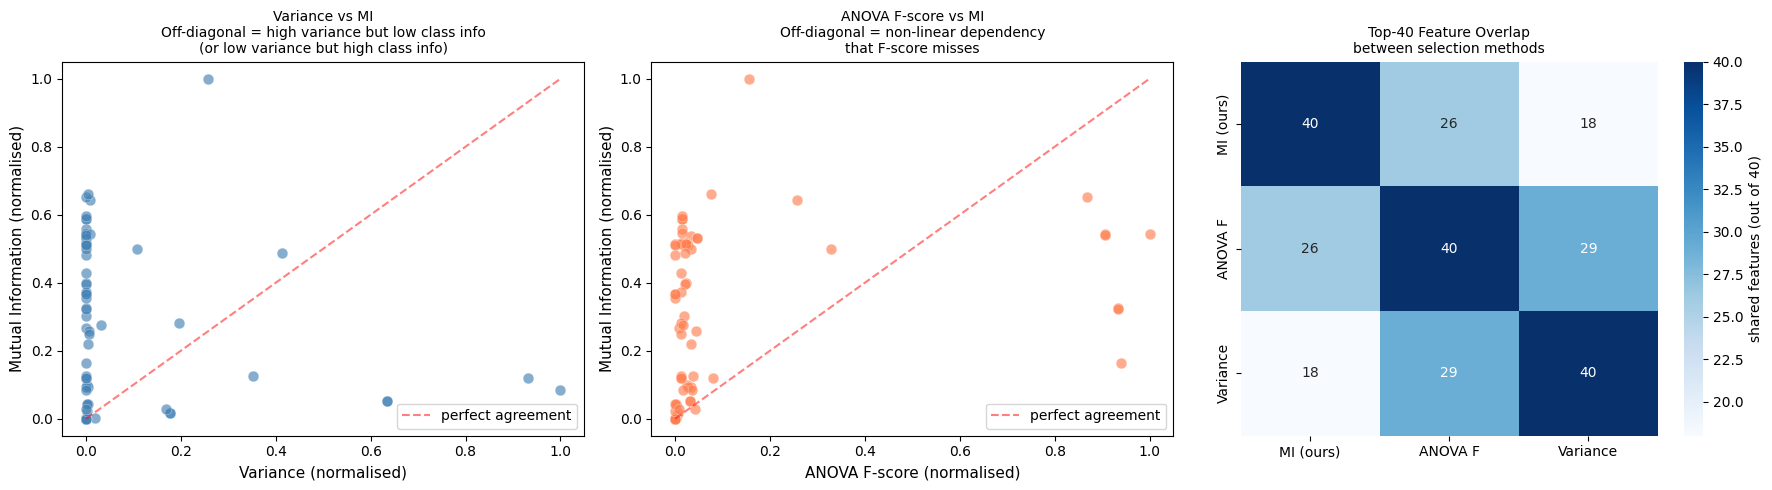

Saved -> results/feature_selection_comparison.png


In [7]:
# ─────────────────────────────────────────────────────────────────────
# CELL 5 — Compare MI with ANOVA F-score and variance
#
# Computes ANOVA F-scores and per-feature variances on the same 200 K sample
# and visualises three comparison scatter plots:
#   1. Variance vs MI — features off the diagonal have high variance but
#      low class-discriminative power (or vice versa).
#   2. ANOVA F vs MI — features above the diagonal carry non-linear
#      dependencies that F-score misses.
#   3. Top-40 overlap heatmap — shows how differently the three methods rank
#      features, justifying the choice of MI over simpler alternatives.
# ─────────────────────────────────────────────────────────────────────
from sklearn.feature_selection import f_classif
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print('Computing ANOVA F-scores and variance on the same sample...')

f_scores, _ = f_classif(X_sample, y_sample)
f_scores     = np.nan_to_num(f_scores, nan=0.0, posinf=0.0)
variances    = np.var(X_sample, axis=0)

def normalise(arr):
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo + 1e-12)

mi_norm  = normalise(mi_scores)
f_norm   = normalise(f_scores)
var_norm = normalise(variances)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(var_norm, mi_norm, alpha=0.65, color='steelblue', edgecolors='white', linewidths=0.3, s=60)
axes[0].plot([0, 1], [0, 1], 'r--', alpha=0.5, label='perfect agreement')
axes[0].set_xlabel('Variance (normalised)', fontsize=11)
axes[0].set_ylabel('Mutual Information (normalised)', fontsize=11)
axes[0].set_title('Variance vs MI\nOff-diagonal = high variance but low class info\n(or low variance but high class info)', fontsize=10)
axes[0].legend()

axes[1].scatter(f_norm, mi_norm, alpha=0.65, color='coral', edgecolors='white', linewidths=0.3, s=60)
axes[1].plot([0, 1], [0, 1], 'r--', alpha=0.5, label='perfect agreement')
axes[1].set_xlabel('ANOVA F-score (normalised)', fontsize=11)
axes[1].set_ylabel('Mutual Information (normalised)', fontsize=11)
axes[1].set_title('ANOVA F-score vs MI\nOff-diagonal = non-linear dependency\nthat F-score misses', fontsize=10)
axes[1].legend()

try:
    top_k
except NameError:
    top_k = 40
top_mi  = set(np.argsort(mi_scores)[-top_k:])
top_f   = set(np.argsort(f_scores)[-top_k:])
top_var = set(np.argsort(variances)[-top_k:])

methods = ['MI (ours)', 'ANOVA F', 'Variance']
sets    = [top_mi, top_f, top_var]
overlap = np.array([[len(a & b) for b in sets] for a in sets])

sns.heatmap(overlap, annot=True, fmt='d', cmap='Blues',
            xticklabels=methods, yticklabels=methods,
            ax=axes[2], cbar_kws={'label': 'shared features (out of 40)'})
axes[2].set_title(f'Top-{top_k} Feature Overlap\nbetween selection methods', fontsize=10)

plt.tight_layout()
plt.savefig('results/feature_selection_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> results/feature_selection_comparison.png')

np.save('models/feat_sel_f_scores.npy',  f_scores)
np.save('models/feat_sel_top_mi.npy',   np.array(sorted(top_mi)))
np.save('models/feat_sel_top_f.npy',    np.array(sorted(top_f)))
np.save('models/feat_sel_top_var.npy',  np.array(sorted(top_var)))


=== Why Mutual Information over ANOVA F-score? ===

Feature idx    MI score   MI rank     F-score    F rank   Rank diff
----------------------------------------------------------------------

  Top features MI catches that ANOVA misses (non-linear dependencies):
  Feature   5   MI=0.2930  rank= 58   F=      1.01  rank=  9   Drank=+ 49
  Feature  64   MI=0.2916  rank= 54   F=      1.01  rank= 10   Drank=+ 44
  Feature  23   MI=0.3404  rank= 73   F=    336.60  rank= 36   Drank=+ 37
  Feature  35   MI=0.2742  rank= 49   F=      3.00  rank= 13   Drank=+ 36
  Feature  20   MI=0.3349  rank= 72   F=    343.92  rank= 37   Drank=+ 35

  Features ANOVA ranks high that MI does not (linear but not discriminative):
  Feature  48   MI=0.0157  rank= 15   F=    994.54  rank= 62   Drank= -47
  Feature  67   MI=0.0931  rank= 32   F=  22219.58  rank= 76   Drank= -44
  Feature  47   MI=0.0684  rank= 28   F=   1875.05  rank= 67   Drank= -39
  Feature  46   MI=0.0487  rank= 23   F=    855.70  rank= 60   Dra

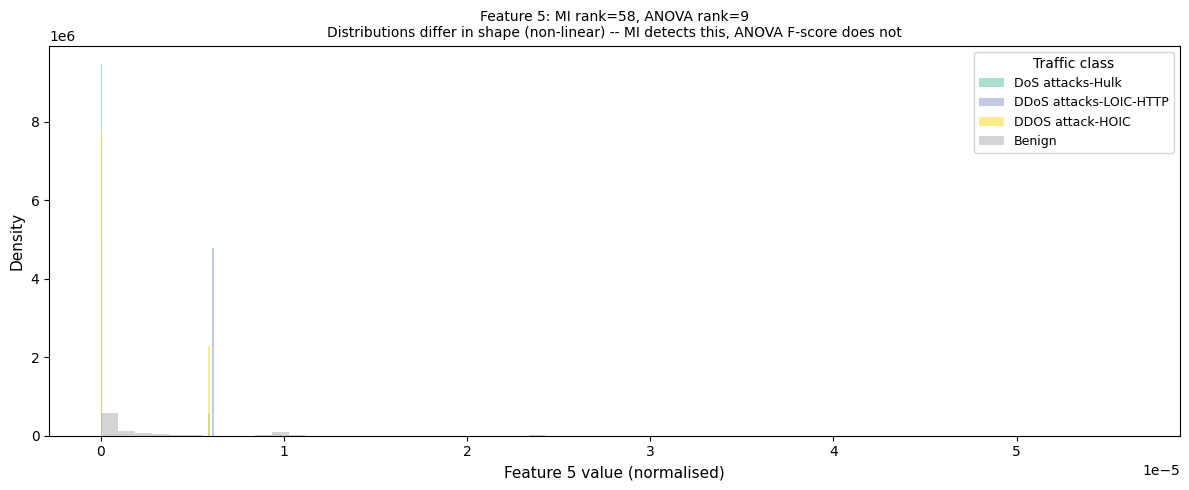

Saved -> results/mi_nonlinear_demo.png

=== Summary: Why MI for feature selection? ===
  MI top-40 vs ANOVA F top-40: only 26/40 features overlap
  MI top-40 vs Variance top-40: only 18/40 features overlap
  MI uniquely selects 14 features not in ANOVA top-40


In [8]:
# ─────────────────────────────────────────────────────────────────────
# CELL 6 — Detailed MI-vs-ANOVA analysis and demo plot
#
# Identifies the features where MI rank and ANOVA rank diverge most and
# prints them with scores from both methods.
# Plots the per-class distribution of the most strongly non-linear feature
# to show visually why MI detects signal that ANOVA F-score misses.
# Saved to results/mi_nonlinear_demo.png.
# ─────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
import joblib

_P = 'models'
try:
    mi_scores, f_scores, X_sample, y_sample
except NameError:
    mi_scores = np.load(f'{_P}/feat_sel_mi_scores.npy')
    f_scores  = np.load(f'{_P}/feat_sel_f_scores.npy')
    X_sample  = np.load(f'{_P}/feat_sel_X_sample.npy')
    y_sample  = np.load(f'{_P}/feat_sel_y_sample.npy')

try:
    top_mi, top_f, top_var, top_k
except NameError:
    top_mi  = set(np.load(f'{_P}/feat_sel_top_mi.npy'))
    top_f   = set(np.load(f'{_P}/feat_sel_top_f.npy'))
    top_var = set(np.load(f'{_P}/feat_sel_top_var.npy'))
    top_k   = 40

le = joblib.load(f'{_P}/label_encoder.pkl')

mi_rank   = np.argsort(np.argsort(mi_scores))
f_rank    = np.argsort(np.argsort(f_scores))
rank_diff = mi_rank.astype(int) - f_rank.astype(int)
nonlinear_candidates = np.argsort(rank_diff)[-5:]
linear_only          = np.argsort(rank_diff)[:5]

print('=== Why Mutual Information over ANOVA F-score? ===\n')
print(f"{'Feature idx':>11}  {'MI score':>10}  {'MI rank':>8}  {'F-score':>10}  {'F rank':>8}  {'Rank diff':>10}")
print('-' * 70)

print('\n  Top features MI catches that ANOVA misses (non-linear dependencies):')
for idx in nonlinear_candidates[::-1]:
    print(f'  Feature {idx:>3}   MI={mi_scores[idx]:.4f}  rank={mi_rank[idx]+1:>3}   '
          f'F={f_scores[idx]:>10.2f}  rank={f_rank[idx]+1:>3}   '
          f'Drank=+{rank_diff[idx]:>3}')

print('\n  Features ANOVA ranks high that MI does not (linear but not discriminative):')
for idx in linear_only:
    print(f'  Feature {idx:>3}   MI={mi_scores[idx]:.4f}  rank={mi_rank[idx]+1:>3}   '
          f'F={f_scores[idx]:>10.2f}  rank={f_rank[idx]+1:>3}   '
          f'Drank={rank_diff[idx]:>4}')

demo_feat = nonlinear_candidates[-1]
class_ids, class_sizes = np.unique(y_sample, return_counts=True)
selected_classes = class_ids[np.argsort(class_sizes)[-4:]]

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.Set2(np.linspace(0, 1, len(selected_classes)))

for cls, col in zip(selected_classes, colors):
    vals = X_sample[y_sample == cls, demo_feat]
    lo, hi = np.percentile(vals, [2, 98])
    vals = vals[(vals >= lo) & (vals <= hi)]
    ax.hist(vals, bins=60, alpha=0.55, color=col, label=le.classes_[cls], density=True)

ax.set_xlabel(f'Feature {demo_feat} value (normalised)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(
    f'Feature {demo_feat}: MI rank={mi_rank[demo_feat]+1}, ANOVA rank={f_rank[demo_feat]+1}\n'
    f'Distributions differ in shape (non-linear) -- MI detects this, ANOVA F-score does not',
    fontsize=10
)
ax.legend(title='Traffic class', fontsize=9)
plt.tight_layout()
plt.savefig('results/mi_nonlinear_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> results/mi_nonlinear_demo.png')

mi_f_overlap   = len(top_mi & top_f)
mi_var_overlap = len(top_mi & top_var)
print(f'\n=== Summary: Why MI for feature selection? ===')
print(f'  MI top-{top_k} vs ANOVA F top-{top_k}: only {mi_f_overlap}/{top_k} features overlap')
print(f'  MI top-{top_k} vs Variance top-{top_k}: only {mi_var_overlap}/{top_k} features overlap')
print(f'  MI uniquely selects {top_k - mi_f_overlap} features not in ANOVA top-{top_k}')


In [9]:
# ─────────────────────────────────────────────────────────────────────
# CELL 7 — Apply MI feature selection to all splits
#
# Indexes all three splits (train, val, test) with the selected_indices array
# to produce 77 → 40 feature matrices.
# Uses a try/except to reload selected_indices from disk if this cell is run
# after a kernel restart, making the cell standalone without re-running cell 4.
# ─────────────────────────────────────────────────────────────────────
# Apply selection to all splits
try:
    selected_indices
except NameError:
    selected_indices = np.load('models/selected_indices.npy')

X_train_selected = X_train[:, selected_indices]
X_val_selected   = X_val[:, selected_indices]
X_test_selected  = X_test[:, selected_indices]

print(f"After selection - Train: {X_train_selected.shape}")
print(f"After selection - Val:   {X_val_selected.shape}")
print(f"After selection - Test:  {X_test_selected.shape}")


After selection - Train: (18412356, 40)
After selection - Val:   (2434941, 40)
After selection - Test:  (2434942, 40)


In [16]:
# ─────────────────────────────────────────────────────────────────────
# CELL 8 — Scale latent features and build hybrid feature matrix
#
# Fits MinMaxScaler on the pre-SMOTE latent encodings (X_ae_latent_for_scale)
# rather than the SMOTE latent encodings. SMOTE rows are linear interpolations
# between real flows, so their latent values cluster toward class centroids and
# understate the true dynamic range; fitting the scaler on real-traffic
# encodings gives each latent dim a faithful [min, max] so real test flows are
# scaled consistently. (With the linear bottleneck the latent is signed, so the
# scaler also correctly maps negative latent values into [0,1].)
# Concatenates the 40 MI-selected features with the 16 scaled latent
# dimensions to produce the final 56-feature hybrid matrix used for training.
# ─────────────────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler

# Fit the scaler on encodings of REAL (pre-SMOTE) traffic so each latent
# dimension is scaled by its genuine range rather than the compressed range of
# SMOTE-interpolated samples.
latent_scaler = MinMaxScaler()
latent_scaler.fit(X_ae_latent_for_scale)   # fit on real-data encodings

X_train_latent_scaled = latent_scaler.transform(X_train_latent)
X_val_latent_scaled   = latent_scaler.transform(X_val_latent)
X_test_latent_scaled  = latent_scaler.transform(X_test_latent)

X_train_hybrid = np.concatenate([X_train_selected, X_train_latent_scaled], axis=1)
X_val_hybrid   = np.concatenate([X_val_selected,   X_val_latent_scaled],   axis=1)
X_test_hybrid  = np.concatenate([X_test_selected,  X_test_latent_scaled],  axis=1)

print(f'Hybrid train shape: {X_train_hybrid.shape}')
print(f'Hybrid val shape:   {X_val_hybrid.shape}')
print(f'Hybrid test shape:  {X_test_hybrid.shape}')
print(f'\nBreakdown: {X_train_selected.shape[1]} handcrafted + {X_train_latent_scaled.shape[1]} latent = {X_train_hybrid.shape[1]} total features')

Hybrid train shape: (18412356, 56)
Hybrid val shape:   (2434941, 56)
Hybrid test shape:  (2434942, 56)

Breakdown: 40 handcrafted + 16 latent = 56 total features


In [17]:
# ─────────────────────────────────────────────────────────────────────
# CELL 9 — Save hybrid feature arrays, latent scaler, and class weights
#
# Saves the 56-feature hybrid arrays (X_train_hybrid, X_val_hybrid,
# X_test_hybrid) to data/features/ and the latent_scaler to models/.
# Also saves selected_indices.npy so the inference pipeline can apply
# the same feature selection to new traffic without rerunning this notebook.
# Finally computes 'balanced' class weights from y_train and saves them so
# downstream training can counter the ~3000:1 residual class imbalance
# (the SMOTE step only partially oversampled minorities — see Cell 0).
# ─────────────────────────────────────────────────────────────────────
import numpy as np
import joblib
import os
from sklearn.utils.class_weight import compute_class_weight

os.makedirs('data/features', exist_ok=True)

np.save('data/features/X_train_hybrid.npy', X_train_hybrid)
np.save('data/features/X_val_hybrid.npy',   X_val_hybrid)
np.save('data/features/X_test_hybrid.npy',  X_test_hybrid)

np.save('models/selected_indices.npy', selected_indices)
joblib.dump(latent_scaler, 'models/latent_scaler.pkl')

# Balanced class weights for downstream training (inverse-frequency).
# Reload y_train if this cell is run standalone after a kernel restart.
try:
    y_train
except NameError:
    y_train = np.load('data/processed/y_train.npy')

classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
np.save('models/class_weights.npy', class_weights)
print('Class weights (balanced) — pass these to the classifier:')
le_local = joblib.load('models/label_encoder.pkl')
for c, w in zip(classes, class_weights):
    print(f'  {le_local.classes_[c][:26]:<28} weight={w:8.3f}')

# Verify all files were actually written
print()
for path in [
    'data/features/X_train_hybrid.npy',
    'data/features/X_val_hybrid.npy',
    'data/features/X_test_hybrid.npy',
    'models/selected_indices.npy',
    'models/latent_scaler.pkl',
    'models/class_weights.npy',
]:
    size_mb = os.path.getsize(path) / (1024**2)
    print(f"  {os.path.basename(path)}: {size_mb:.1f} MB")

print("\nAll hybrid features, latent_scaler, and class_weights saved successfully!")
print(f"Final feature space: {X_train_hybrid.shape[1]} features per flow")
print("Phase 3 complete! Ready for model training.")

Class weights (balanced) — pass these to the classifier:
  Benign                       weight=   0.130
  Bot                          weight=   1.300
  Brute Force -Web             weight=  57.359
  Brute Force -XSS             weight= 152.483
  DDOS attack-HOIC             weight=   1.300
  DDOS attack-LOIC-UDP         weight=  20.272
  DDoS attacks-LOIC-HTTP       weight=   1.300
  DoS attacks-GoldenEye        weight=   1.300
  DoS attacks-Hulk             weight=   1.300
  DoS attacks-SlowHTTPTest     weight=   1.300
  DoS attacks-Slowloris        weight=   3.191
  FTP-BruteForce               weight=   1.300
  Infilteration                weight=   1.300
  SQL Injection                weight= 402.456
  SSH-Bruteforce               weight=   1.300

  X_train_hybrid.npy: 3933.3 MB
  X_val_hybrid.npy: 520.2 MB
  X_test_hybrid.npy: 520.2 MB
  selected_indices.npy: 0.0 MB
  latent_scaler.pkl: 0.0 MB
  class_weights.npy: 0.0 MB

All hybrid features, latent_scaler, and class_weights save

In [12]:
# ─────────────────────────────────────────────────────────────────────
# CELL 10 — Verify saved file sizes
#
# Confirms that the three hybrid .npy files were written correctly by
# printing their sizes in GB. Expected: ~2.3 GB (train), ~0.3 GB (val/test).
# ─────────────────────────────────────────────────────────────────────
import os
files = [
    'data/features/X_train_hybrid.npy',
    'data/features/X_val_hybrid.npy',
    'data/features/X_test_hybrid.npy'
]
for f in files:
    size = os.path.getsize(f) / (1024**3)
    print(f"{os.path.basename(f)}: {size:.2f} GB")

X_train_hybrid.npy: 3.84 GB
X_val_hybrid.npy: 0.51 GB
X_test_hybrid.npy: 0.51 GB
